# 👩‍💻 **Sample from a Simple Generative Model**

**Time Estimate:** 45 minutes

## 📋 **Overview**

In this activity, learners will delve into one of the fundamental processes of generative modeling—using a Gaussian Mixture Model (GMM) to generate data. You'll learn to construct this model using PyTorch and explore how it can create new samples that reflect an original dataset. This understanding is key for roles in data science, AI development, and machine learning engineering because it shows how generative models can replicate and simulate data characteristics useful in data augmentation, simulations, and creative industries.

## 🎯 **Learning Outcomes**

By the end of this lab, you will be able to:

- Create and train a Gaussian Mixture Model using PyTorch.
- Generate new data samples that mimic the original data distribution.
- Analyze and compare generated data with real data to assess generative model success.

## Task 1: Data Preparation [15 minutes]

In [1]:
# imports
import numpy as np
import torch
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture


1.  Generate a synthetic 2D Gaussian dataset and visualize its distribution.

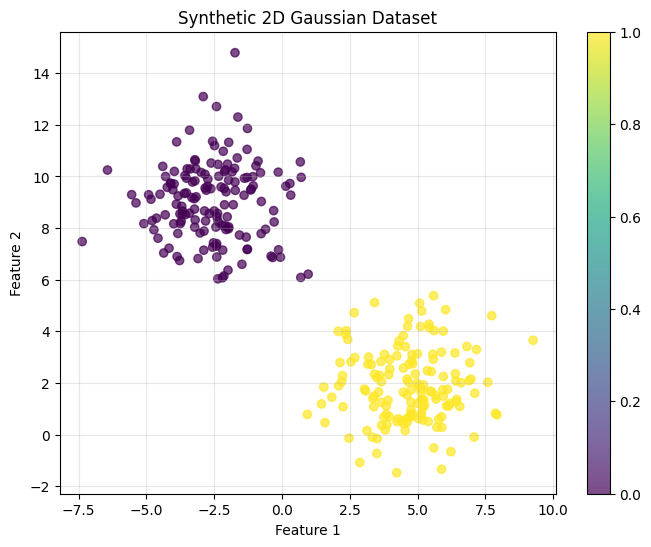

Dataset shape: (300, 2)
Number of clusters: 2


In [2]:
# Task 1
# your code here...

# Generate synthetic 2D Gaussian dataset
X, y = make_blobs(n_samples=300, centers=2, n_features=2, 
                  random_state=42, cluster_std=1.5)

# Visualize the data
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', alpha=0.7)
plt.title('Synthetic 2D Gaussian Dataset')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.colorbar()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Dataset shape: {X.shape}")
print(f"Number of clusters: {len(set(y))}")

✅ **Success Checklist**

- The data visualization correctly shows two distinct clusters.
- Identify distinct clusters based on your visual assessment.

💡 **Key Points**

- Synthetic data generation is useful for controlled experiments.
- Visual exploration of data is crucial to understand underlying patterns.

❗ **Common Mistakes to Avoid**

- Choosing inappropriate cluster parameters (too many or too few centers).
- Not setting a random state, making results irreproducible.
- Creating visualizations without proper labels or legends.

## Task 2: Model Implementation and Training [20 minutes]
Build and fit a Gaussian Mixture Model using PyTorch to your dataset.
1.  Define and train Gaussian Mixture Model
2.  Use the data to estimate the parameters of your GMM.
3.  Ensure that the model parameters capture the original data distribution effectively.

In [3]:
# Task 2
# your code here...

# Define and train Gaussian Mixture Model
gmm = GaussianMixture(n_components=2, covariance_type='full', random_state=42)
gmm.fit(X)

# Print model parameters
print("GMM Training Complete!")
print(f"Converged: {gmm.converged_}")
print(f"Number of iterations: {gmm.n_iter_}")
print(f"Log likelihood: {gmm.score(X):.2f}")

# Display learned parameters
print("\nLearned cluster centers:")
for i, mean in enumerate(gmm.means_):
    print(f"Cluster {i+1}: ({mean[0]:.2f}, {mean[1]:.2f})")

print(f"\nCluster weights: {gmm.weights_}")

GMM Training Complete!
Converged: True
Number of iterations: 2
Log likelihood: -4.28

Learned cluster centers:
Cluster 1: (-2.57, 9.04)
Cluster 2: (4.67, 1.90)

Cluster weights: [0.49983116 0.50016884]


✅ **Success Checklist**

- The model correctly identifies clusters similar to the original dataset.
- Parameters (means and covariances) are accurate based on data patterns.

💡 **Key Points**

- The number of components in GMM should match the true number of clusters in your data.
- Convergence indicates the model has found stable parameter estimates.
- Log likelihood provides a measure of how well the model fits the data.

❗ **Common Mistakes to Avoid**

- Using too many components, leading to overfitting.
- Not checking convergence before proceeding to generate samples.
- Ignoring the covariance type parameter which affects model complexity.

## Task 3: Sampling New Data and Comparison [10 minutes]
Use the trained model to generate new data and compare.
1. Sample new data
2. Visualize combined data
3. Sample new data points from the trained GMM.
4. Use visualization to assess similarity to the original distribution.

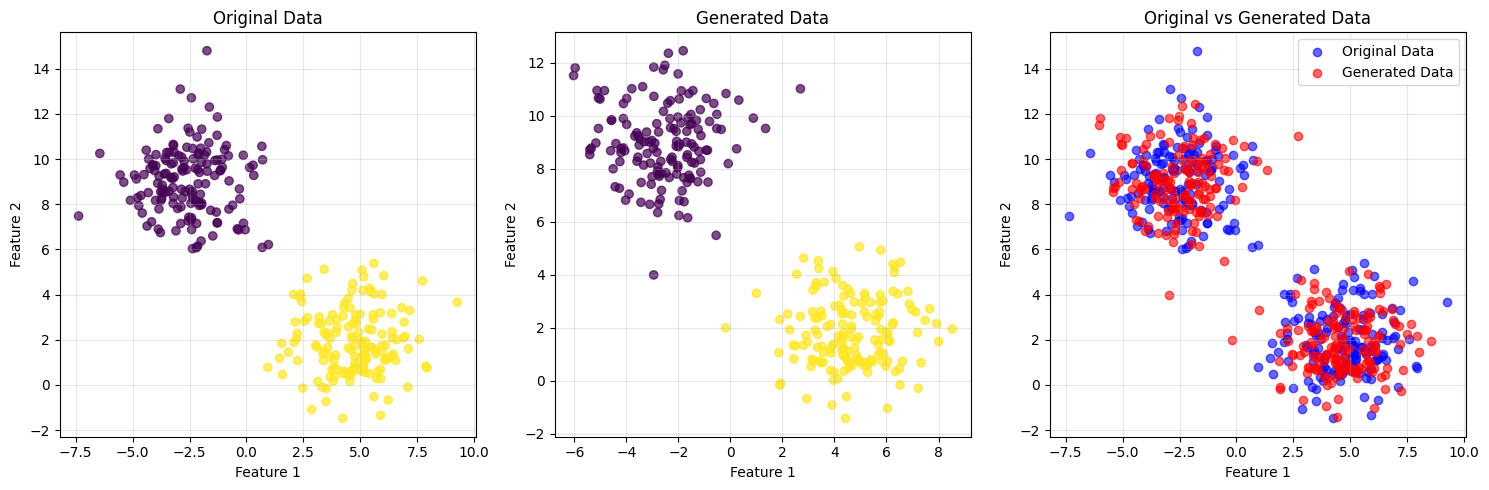

Statistical Comparison:
Original data mean: (1.05, 5.46)
Generated data mean: (1.18, 5.27)
Original data std: (3.91, 3.85)
Generated data std: (3.88, 3.83)


In [4]:
# Task 3
# your code here ...

# Sample new data from the trained GMM
X_generated, y_generated = gmm.sample(n_samples=300)
    
# Visualize original vs generated data
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))

# Original data
ax1.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', alpha=0.7)
ax1.set_title('Original Data')
ax1.set_xlabel('Feature 1')
ax1.set_ylabel('Feature 2')
ax1.grid(True, alpha=0.3)

# Generated data
ax2.scatter(X_generated[:, 0], X_generated[:, 1], c=y_generated, cmap='viridis', alpha=0.7)
ax2.set_title('Generated Data')
ax2.set_xlabel('Feature 1')
ax2.set_ylabel('Feature 2')
ax2.grid(True, alpha=0.3)

# Combined comparison
ax3.scatter(X[:, 0], X[:, 1], c='blue', alpha=0.6, label='Original Data')
ax3.scatter(X_generated[:, 0], X_generated[:, 1], c='red', alpha=0.6, label='Generated Data')
ax3.set_title('Original vs Generated Data')
ax3.set_xlabel('Feature 1')
ax3.set_ylabel('Feature 2')
ax3.legend()
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Statistical comparison
print("Statistical Comparison:")
print(f"Original data mean: ({np.mean(X[:, 0]):.2f}, {np.mean(X[:, 1]):.2f})")
print(f"Generated data mean: ({np.mean(X_generated[:, 0]):.2f}, {np.mean(X_generated[:, 1]):.2f})")
print(f"Original data std: ({np.std(X[:, 0]):.2f}, {np.std(X[:, 1]):.2f})")
print(f"Generated data std: ({np.std(X_generated[:, 0]):.2f}, {np.std(X_generated[:, 1]):.2f})")

✅ **Success Checklist**

- A clear overlap or similarity in distribution between real and generated data.
- Generate appropriately phased samples.

💡 **Key Points**

- The ability to generate data statistically similar to real data has vast applications, from data fill-ins to novel creations.
- Visual comparisons are crucial for assessing model accuracy in generative tasks.

❗ **Common Mistakes to Avoid**

- Not checking the fit of the model thoroughly before generating samples.
- Overlooking discrepancies in mean and variance when comparing real and generated datasets.

🚀 **Next Steps**

In the next module, you will learn how to extend these foundational skills by experimenting with other types of generative models such as VAEs and Autoregressive Models. This builds on the concepts of distribution modeling and sampling to enhance your ability to create and control generative outputs effectively.

## 💻 Exemplar Solution

<details>    
<summary><strong>Click HERE to see an exemplar solution</strong></summary>

### Task 1 Solution
    
```python
# Generate synthetic 2D Gaussian dataset
X, y = make_blobs(n_samples=300, centers=2, n_features=2, 
                  random_state=42, cluster_std=1.5)

# Visualize the data
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', alpha=0.7)
plt.title('Synthetic 2D Gaussian Dataset')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.colorbar()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Dataset shape: {X.shape}")
print(f"Number of clusters: {len(set(y))}")
```

### Task 2 Solution
    
```python
from sklearn.mixture import GaussianMixture
import numpy as np

# Define and train Gaussian Mixture Model
gmm = GaussianMixture(n_components=2, covariance_type='full', random_state=42)
gmm.fit(X)

# Print model parameters
print("GMM Training Complete!")
print(f"Converged: {gmm.converged_}")
print(f"Number of iterations: {gmm.n_iter_}")
print(f"Log likelihood: {gmm.score(X):.2f}")

# Display learned parameters
print("\nLearned cluster centers:")
for i, mean in enumerate(gmm.means_):
    print(f"Cluster {i+1}: ({mean[0]:.2f}, {mean[1]:.2f})")

print(f"\nCluster weights: {gmm.weights_}")
```

### Task 3 Solution

```python
# Sample new data from the trained GMM
X_generated, y_generated = gmm.sample(n_samples=300)
    
# Visualize original vs generated data
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))

# Original data
ax1.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', alpha=0.7)
ax1.set_title('Original Data')
ax1.set_xlabel('Feature 1')
ax1.set_ylabel('Feature 2')
ax1.grid(True, alpha=0.3)

# Generated data
ax2.scatter(X_generated[:, 0], X_generated[:, 1], c=y_generated, cmap='viridis', alpha=0.7)
ax2.set_title('Generated Data')
ax2.set_xlabel('Feature 1')
ax2.set_ylabel('Feature 2')
ax2.grid(True, alpha=0.3)

# Combined comparison
ax3.scatter(X[:, 0], X[:, 1], c='blue', alpha=0.6, label='Original Data')
ax3.scatter(X_generated[:, 0], X_generated[:, 1], c='red', alpha=0.6, label='Generated Data')
ax3.set_title('Original vs Generated Data')
ax3.set_xlabel('Feature 1')
ax3.set_ylabel('Feature 2')
ax3.legend()
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Statistical comparison
print("Statistical Comparison:")
print(f"Original data mean: ({np.mean(X[:, 0]):.2f}, {np.mean(X[:, 1]):.2f})")
print(f"Generated data mean: ({np.mean(X_generated[:, 0]):.2f}, {np.mean(X_generated[:, 1]):.2f})")
print(f"Original data std: ({np.std(X[:, 0]):.2f}, {np.std(X[:, 1]):.2f})")
print(f"Generated data std: ({np.std(X_generated[:, 0]):.2f}, {np.std(X_generated[:, 1]):.2f})")
```
</details>